Nom : KARBOUN Ahmed Master : GLCC

In [17]:
# étudiant test
# ↓
#
# normalisation
# ↓
#
# calcul distances euclidiennes
# ↓
#
# tri croissant distances
# ↓
#
# sélection K voisins
#
#------------------------------------------
#
# KNN CLASSIFICATION
#
# vote majoritaire
#
# [1,1,0]
#
# -> classe finale = 1
#
#------------------------------------------
#
# KNN RÉGRESSION
#
# moyenne des voisins
#
# exemple :
#
# [10 , 11 , 9]
#
#                10+11+9
# moyenne = ----------------
#                    3
#
# moyenne = 10
#
#------------------------------------------
#
# petit K :
#
# -> overfitting
# -> sensible au bruit
#
#------------------------------------------
#
# grand K :
#
# -> underfitting
# -> trop généralisé
#
#------------------------------------------

In [18]:
import numpy as np
import matplotlib.pyplot as plt

In [19]:

# F1 = heures d'étude
# F2 = participation
# F3 = exercices rendus
# F4 = score contrôle
# F5 = absences
# F6 = projets
#
#------------------------------------------

X = np.array([ # la matrice des caractéristiques (features)  ## dataset de 27 étudiants avec 6 caractéristiques chacun

    [2,5,8,20,0,6],
    [4,6,6,40,2,5],
    [6,7,5,60,3,4],
    [8,7,4,80,4,3],
    [10,8,3,90,5,2],
    [3,4,9,30,0,7],
    [7,6,5,70,3,4],

    [5,5,6,50,2,5],
    [9,8,4,85,4,3],
    [1,3,9,15,1,8],
    [6,6,5,65,3,4],
    [7,7,4,75,3,3],
    [8,8,3,88,4,2],
    [2,4,8,25,1,6],
    [3,5,7,35,2,6],

    [4,7,6,45,2,5],
    [5,6,6,55,3,4],
    [6,8,5,68,3,3],
    [7,5,5,72,4,3],
    [9,7,4,82,4,2],

    [10,9,3,95,5,1],
    [2,3,9,10,1,9],
    [3,4,8,28,2,7],
    [6,5,6,60,3,4],
    [7,6,5,70,3,3],
    [8,7,4,78,4,2],
    [9,8,3,88,5,2]

])

notes = np.array([  # les notes finales (target) pour les 27 étudiants

    10,13,15,17,18.5,11,16,
    12,17,9,14,15,18,10,11,
    13,14,15,16,17,
    19,8,9,14,15,16,17

])

print("Shape X =", X.shape)   # Affiche la forme de la matrice X (27, 6) -> 27 étudiants et 6 caractéristiques
print("Shape notes =", notes.shape) # Affiche la forme du vecteur notes (27

print("Nombre étudiants =", len(notes))  # Affiche le nombre d'étudiants (27) en utilisant la longueur du vecteur notes

Shape X = (27, 6)
Shape notes = (27,)
Nombre étudiants = 27


In [20]:
# note >= 12 :
# réussite
#
# sinon :
# échec
#
#------------------------------------------

y_normal = (notes >= 12).astype(int)   # Convertit les notes en classes binaires : 1 pour réussite (note >= 12) et 0 pour échec (note < 12)

print(y_normal)  # Affiche les classes binaires pour chaque étudiant (1 pour réussite, 0 pour échec)

[0 1 1 1 1 0 1 1 1 0 1 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 1]


In [21]:
# on garde uniquement :
#
# étudiants en échec
#
#------------------------------------------

X_rattrapage = X[y_normal == 0]   # Sélectionne les lignes de la matrice X correspondant aux étudiants en échec (y_normal == 0)

notes_rattrapage = notes[y_normal == 0]   # Sélectionne les notes correspondantes aux étudiants en échec

print("Nombre étudiants rattrapage =")

print(len(X_rattrapage))    # Affiche le nombre d'étudiants en échec (rattrapage) en utilisant la longueur de la matrice X_rattrapage

Nombre étudiants rattrapage =
7


In [22]:
# note >= 10 :
# réussite rattrapage
#
# sinon :
# échec
#
#------------------------------------------

y_rattrapage = (

    notes_rattrapage >= 10

).astype(int)   # Convertit les notes des étudiants en échec en classes binaires pour le rattrapage : 1 pour réussite (note >= 10) et 0 pour échec (note < 10)

print(y_rattrapage)

[1 1 0 1 1 0 0]


In [23]:
#               x - μ
# x_norm = ----------------
#                  σ
#
#------------------------------------------

X_mean = np.mean(

    X_rattrapage,
    axis=0

)   # Calcule la moyenne de chaque caractéristique (colonne) dans la matrice X_rattrapage, en spécifiant axis=0 pour calculer la moyenne le long des colonnes

X_std = np.std(

    X_rattrapage,
    axis=0

)   # Calcule l'écart type de chaque caractéristique (colonne) dans la matrice X_rattrapage, en spécifiant axis=0 pour calculer l'écart type le long des colonnes

X_norm = (

    X_rattrapage - X_mean

) / X_std  # Normalise les données de X_rattrapage en soustrayant la moyenne et en divisant par l'écart type pour chaque caractéristique

print(X_norm[:3])  # Affiche les 3 premières lignes de la matrice normalisée X_norm pour vérifier les résultats de la normalisation

[[-0.40824829  1.32287566 -0.40824829 -0.40381962 -1.32287566 -0.93541435]
 [ 1.02062073  0.          1.02062073  0.82519661 -1.32287566  0.        ]
 [-1.83711731 -1.32287566  1.02062073 -1.01832773  0.          0.93541435]]


In [24]:
# d(x,y)= √ Σ (xi-yi)^2
#                   i=1
#
#------------------------------------------

def distance_euclidienne(x1, x2):

    return np.sqrt(

        np.sum((x1 - x2) ** 2)

    )  # Calcule la distance euclidienne entre deux points x1 et x2 en utilisant la formule de la distance euclidienne : d(x,y) = √(Σ (xi - yi)^2)

In [25]:
# vote majoritaire

def knn_classification(

    X_train,
    y_train,
    x_test,
    K=3

):   # K = nombre de voisins à considérer

    distances = []

    for i in range(len(X_train)):

        d = distance_euclidienne(

            x_test,
            X_train[i]

        )  # Calcule la distance euclidienne entre le point de test x_test et chaque point d'entraînement X_train[i] en utilisant la fonction distance_euclidienne définie précédemment

        distances.append(

            (d, y_train[i])

        )  # Ajoute un tuple (distance, classe) à la liste distances pour chaque point d'entraînement, où distance est la distance calculée et classe est la classe correspondante y_train[i]

    distances.sort(

        key=lambda x: x[0]

    )  # Trie la liste distances en fonction de la distance (le premier élément du tuple) en utilisant la méthode sort() avec une fonction lambda comme clé de tri

    k_voisins = distances[:K]  # Sélectionne les K premiers éléments de la liste distances triée pour obtenir les K voisins les plus proches, qui sont stockés dans la variable k_voisins

    print(f"\nK = {K}")

    print("\nVoisins :\n")

    for voisin in k_voisins:

        print(voisin)

    classes_voisins = [

        v[1]

        for v in k_voisins

    ]  # Crée une liste classes_voisins qui contient les classes des K voisins les plus proches en extrayant le deuxième élément de chaque tuple dans k_voisins (v[1] correspond à la classe du voisin)

    prediction = max(

        set(classes_voisins),

        key=classes_voisins.count

    )

    return prediction # Effectue un vote majoritaire pour déterminer la classe prédite en utilisant la fonction max() avec une clé de comptage (classes_voisins.count) pour trouver la classe qui apparaît le plus fréquemment parmi les K voisins les plus proches, et retourne cette classe comme prédiction

In [26]:
# KNN RÉGRESSION
# moyenne des voisins

def knn_regression(

    X_train,
    y_train,
    x_test,
    K=3

): # K = nombre de voisins à considérer

    distances = []

    for i in range(len(X_train)):

        d = distance_euclidienne(

            x_test,
            X_train[i]

        ) # Calcule la distance euclidienne entre le point de test x_test et chaque point d'entraînement X_train[i] en utilisant la fonction distance_euclidienne définie précédemment

        distances.append(

            (d, y_train[i])

        ) # Ajoute un tuple (distance, valeur) à la liste distances pour chaque point d'entraînement, où distance est la distance calculée et valeur est la valeur correspondante y_train[i] (note finale dans ce cas)

    distances.sort(

        key=lambda x: x[0]

    )

    k_voisins = distances[:K]  # Sélectionne les K premiers éléments de la liste distances triée pour obtenir les K voisins les plus proches, qui sont stockés dans la variable k_voisins

    print(f"\nK = {K}")

    print("\nVoisins régression :\n")

    for voisin in k_voisins: # Affiche les K voisins les plus proches pour la régression, où chaque voisin est représenté par un tuple (distance, valeur) contenant la distance euclidienne et la valeur correspondante (note finale) du voisin

        print(voisin)

    valeurs = [

        v[1]

        for v in k_voisins

    ]

    prediction = np.mean(valeurs) # Calcule la prédiction pour la régression en prenant la moyenne des valeurs des K voisins les plus proches, où valeurs est une liste contenant les valeurs correspondantes (notes finales) des K voisins, et retourne cette moyenne comme prédiction

    return prediction

In [27]:
etudiant_test = np.array([  # les caractéristiques d'un nouvel étudiant pour lequel on veut faire une prédiction

    [3,4,8,30,1,7]

])

x_test_norm = ( # normalisation du point de test en utilisant la même moyenne et écart type que pour les données d'entraînement

    etudiant_test - X_mean

) / X_std

print(x_test_norm) # Affiche les caractéristiques normalisées du nouvel étudiant pour lequel on veut faire une prédiction, en utilisant la même moyenne (X_mean) et écart type (X_std) que ceux utilisés pour normaliser les données d'entraînement

[[ 1.02062073  0.         -0.40824829  0.82519661  0.          0.        ]]


In [28]:
liste_k = [1,3,5]  # liste des différentes valeurs de K à tester pour les prédictions

predictions_notes = [] # liste pour stocker les prédictions de notes obtenues avec le KNN régression

predictions_classes = []  # liste pour stocker les prédictions de classes obtenues avec le KNN classification

for K in liste_k:  # boucle pour tester chaque valeur de K dans la liste liste_k

    prediction_note = knn_regression(

        X_norm,     # les données d'entraînement normalisées (caractéristiques des étudiants en échec)
        notes_rattrapage,  # les valeurs cibles correspondantes (notes finales des étudiants en échec)
        x_test_norm,   # les caractéristiques normalisées du nouvel étudiant pour lequel on veut faire une prédiction
        K=K  # le nombre de voisins à considérer pour la régression

    )

    prediction_classe = knn_classification( # appel de la fonction de classification KNN pour obtenir la prédiction de classe (réussite ou échec) pour le même point de test et les mêmes données d'entraînement, en utilisant la même valeur de K

        X_norm,
        y_rattrapage,
        x_test_norm,
        K=K

    )

    predictions_notes.append(   # Ajoute la prédiction de note obtenue avec le KNN régression à la liste predictions_notes pour chaque valeur de K testée

        prediction_note

    )

    predictions_classes.append(   # Ajoute la prédiction de classe obtenue avec le KNN classification à la liste predictions_classes pour chaque valeur de K testée

        prediction_classe   # la classe prédite (1 pour réussite, 0 pour échec) obtenue avec le KNN classification pour le même point de test et les mêmes données d'entraînement, en utilisant la même valeur de K

    )

    print("\n----------------------")

    print(f"K = {K}")

    print(

        f"Note prédite = {prediction_note:.2f}"

    )

    if prediction_classe == 1:  # si la classe prédite est 1 (réussite), afficher "Réussite"

        print("Réussite")

    else: # si la classe prédite est 0 (échec), afficher "Échec"

        print("Échec")


K = 1

Voisins régression :

(np.float64(1.3455182033371804), np.float64(9.0))

K = 1

Voisins :

(np.float64(1.3455182033371804), np.int64(0))

----------------------
K = 1
Note prédite = 9.00
Échec

K = 3

Voisins régression :

(np.float64(1.3455182033371804), np.float64(9.0))
(np.float64(1.8150170491251256), np.float64(10.0))
(np.float64(1.9472202409246537), np.float64(11.0))

K = 3

Voisins :

(np.float64(1.3455182033371804), np.int64(0))
(np.float64(1.8150170491251256), np.int64(1))
(np.float64(1.9472202409246537), np.int64(1))

----------------------
K = 3
Note prédite = 10.00
Réussite

K = 5

Voisins régression :

(np.float64(1.3455182033371804), np.float64(9.0))
(np.float64(1.8150170491251256), np.float64(10.0))
(np.float64(1.9472202409246537), np.float64(11.0))
(np.float64(2.6065852927949393), np.float64(11.0))
(np.float64(2.8155190559574472), np.float64(10.0))

K = 5

Voisins :

(np.float64(1.3455182033371804), np.int64(0))
(np.float64(1.8150170491251256), np.int64(1))
(np.f

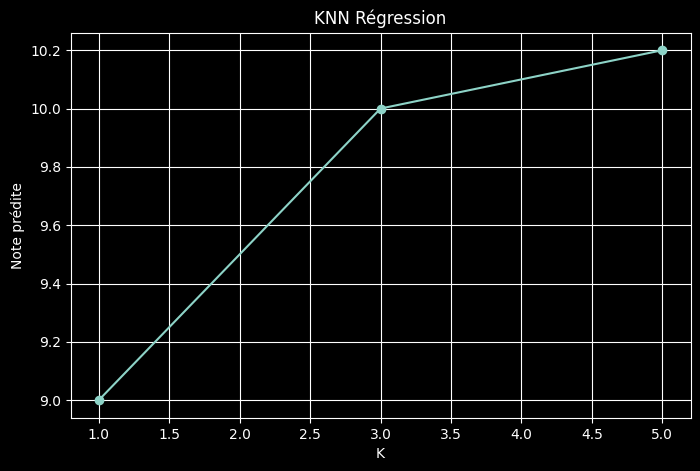

In [29]:
# visualisation des prédictions de notes et de classes en fonction de K
plt.figure(figsize=(8,5))

plt.plot(

    liste_k,
    predictions_notes,
    marker='o'

)

plt.title(

    "KNN Régression"

)

plt.xlabel("K")

plt.ylabel("Note prédite")

plt.grid(True)

plt.show()

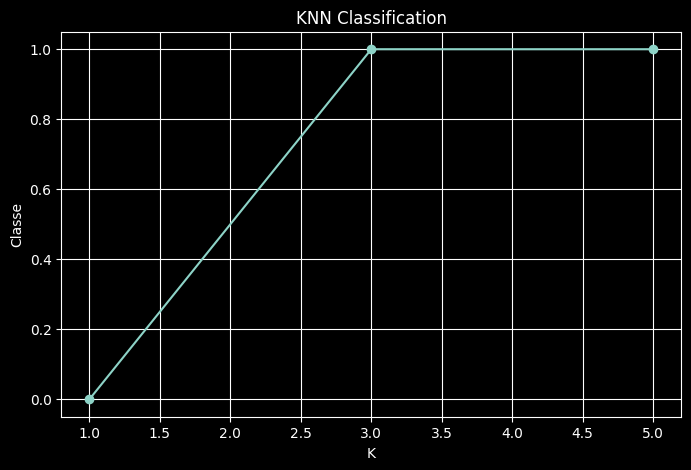

In [30]:
# visualisation des prédictions de classes en fonction de K
plt.figure(figsize=(8,5))

plt.plot(

    liste_k,
    predictions_classes,
    marker='o'

)

plt.title(

    "KNN Classification"

)

plt.xlabel("K")

plt.ylabel("Classe")

plt.grid(True)

plt.show()